# Лабораторная работа №7
# "Аналитика банковских данных.V2 с использованием нейронных сетей"

ЦЕЛЬ РАБОТЫ -  Определить потенциальных клиентов, которые могут просрочить выплату по кредиту

РЕШАЕМАЯ ЗАДАЧА - Написать простейшую нейронную сеть и пайплайн обучения для классификаци для предсказания просрочки выплат по кредиту С НУЛЯ

ХОД РАБОТЫ

1) Взять любую из прошлых лабораторных и данные из нее.
2) Написать простейшую нейронную сеть и пайплайн обучения для классификации/регрессии с нуля.

- Можно использовать pytorch или любой другой фремвок для математических операций.
- Нельзя использовать готовые слои, функции потерь, оптимайзеры и т.д.

3) Обосновать выбор функции активации и функции потерь.
4) Попробовать несколько различных архитектур/конфигураций, провести обучение и сравнить результаты.
- Как минимум модель должна выдавать разумные результаты.

ОПИСАНИЕ ДАННЫХ

Данные таблицы credit_scoring.csv содержат следующую информацию:

●	client_id - ID клиента (неотрицательное целое число)

●	Age - возраст (вещественный)

●	Income - месячный доход (вещественный)

●	BalanceToCreditLimit - отношение баланса на кредитной карте к лимту по кредиту (вещественный)

●	DIR - Debt-to-income Ratio (вещественный)

●	NumLoans - число заемов и кредитных линий

●	NumRealEstateLoans - число ипотек и заемов, связанных с недвижимостью (натуральное число)

●	NumDependents - число членов семьи, которых содержит клиент, исключая самого клиента (натуральное число)

●	Num30-59Delinquencies - число просрочек выплат по кредиту от 30 до 59 дней (натуральное число)

●	Num60-89Delinquencies - число просрочек выплат по кредиту от 60 до 89 дней (натуральное число)

●	Delinquent90 - Таргет, были ли просрочки выплат по кредиту более 90 дней (бинарный)

## Импорт необходимых пакетов

In [1]:
# !pip install torch

In [2]:
import torch
import torch.nn.functional as F
import torch.nn as nn

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

%matplotlib inline

## Шаг 1. Взять любую из прошлых лабораторных и данные из нее

Для данной лабораторной работы была выбрана задача бинарной классификации из лабораторной работы №4, датасет - credit_scoring.csv. Ранее в лабораторной работе 4, в данном датасете была обнаружена проблема дисбаланса классов и большое количество пропусков в признаке Income и неборльшое в  NumDependents, поэтому перед построением пайплайна и обучения модели проведем предобработку), вся статистика нам известна из 4 лабораторной поэтому дублирование информации тут считаю неуместной, чтобы не усложнять структуру тетрадки)

### Загрузка данных

In [3]:
data = pd.read_csv("credit_scoring.csv", sep=',')

In [4]:
# data.shape

### Предобработка

In [5]:
data = data.drop(columns=["client_id"])

In [6]:
data["IncomeMissing"] = data["Income"].isna().astype(int)
data["Income"] = data["Income"].fillna(data["Income"].median())

In [7]:
data["NumDependents"] = data["NumDependents"].fillna(data["NumDependents"].median())

### Разделение данных на Train/Test

In [8]:
X = data.drop(columns=["Delinquent90"]).values.astype(np.float32)
y = data["Delinquent90"].values.astype(np.float32).reshape(-1, 1)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Скалирование

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)
X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)

## Шаг 2-3. Написать простейшую нейронную сеть и пайплайн обучения для классификации/регрессии с нуля. Обосновать выбор функции активации и функции потерь

### В данной работе решается задача БИНАРНОЙ КЛАССИФИКАЦИИ
- архитектура - полносвязная - так как для задачи классификации это оптимальный вариант для наших простых табличных данных
- функция потерь - бинарная кросс-энтропия - BCE - так как у нас задача БИНАРНОЙ КЛАССИФИКАЦИИ, binary_cross_entropy_weighted — учитывает дисбаланс классов через pos_weight
- функция активации выходного слоя - Sigmoid - подходит для задачи бинарной классификации так как принимает значения вероятностей пренадлежности к положительному классу от 0 до 1, что нам и нужно на выходном слое. ИТОГО - на выходе — необходима для бинарной классификации.
- оптимизатор - adam - самый общепринятый оптимизатор, наша задача не исключение
- функция активации скрытых слоев - Leaky ReLu - тоже очень распространенная в использовании функция, которая помогает избегать проблемы умирающего нейрона, даёт более быстрый и плавный градиент чем ReLu. ИТОГО - помогает с градиентами для отрицательных значений, снижая проблему "умирающих нейронов".

Сначала создадим функции для составляющих нашей нейронной сети

Функция потерь ---> но она будет не совсем обычной, она будет увеличивать вклад класса 1 в несколько раз, это нужно чтобы модель умела предсказывать не только класс 0 (модель тогда будет бесполезной). То есть сделаем так чтобы модель ловила класс 1 также как и 0
- BCE = - [y * log(p) + (1 - y) * log(1 - p)]

In [12]:
# def binary_cross_entropy(y_true: torch.Tensor, 
#                          y_pred: torch.Tensor, 
#                          eps: float = 1e-8) -> torch.Tensor:

#     y_pred = torch.clamp(y_pred, eps, 1. - eps)
#     loss = - (y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
#     return torch.mean(loss)

def binary_cross_entropy_weighted(y_true: torch.Tensor, 
                                  y_pred: torch.Tensor, 
                                  pos_weight: float = 1.0,
                                  eps: float = 1e-8) -> torch.Tensor:
    """
    Вычисляет бинарную кросс-энтропию вручную.

    Args:
        y_true (torch.Tensor): Истинные бинарные метки (0 или 1),
                               shape = (N, 1).
        y_pred (torch.Tensor): Предсказанные вероятности класса 1,
                               shape = (N, 1).
        eps (float): Малая константа для числовой стабильности.

    Returns:
        torch.Tensor: Среднее значение бинарной кросс-энтропии.
    """
    y_pred = torch.clamp(y_pred, eps, 1. - eps)

    # w_p * y*log(p) + (1-y)*log(1-p)
    loss = - (pos_weight * y_true * torch.log(y_pred) +
              (1 - y_true) * torch.log(1 - y_pred))
    return torch.mean(loss)

Функции активации ---> 

 Sigmoid σ(z)=1/(1+e^−z)
 
 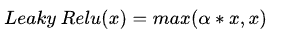

In [13]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

In [14]:
def leaky_relu(x, alpha=0.01):
    return torch.where(x > 0, x, alpha * x)

Оптимизатор Адам ---> Adaptive Moment Estimation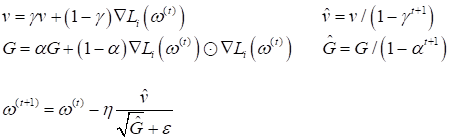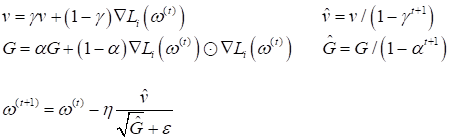

Здесь t+1- номер итерации; v^, G^ - нормированные векторы v, G (нормировка увеличивает v, G на первых итерациях – для ускорения сходимости алгоритма)

In [15]:
def initilization_Adam(params):
    s = {}
    v = {}
    n = len(params)//2

    for i in range(n):
        s["dW"+str(i)] = np.zeros(params["W"+str(i)].shape)
        s["db"+str(i)] = np.zeros(params["b"+str(i)].shape)

        v["dW"+str(i)] = np.zeros(params["W"+str(i)].shape)
        v["db"+str(i)] = np.zeros(params["b"+str(i)].shape)

    return v, s


def update_params_with_Adam(params, grads, v, s, beta1, beta2, lr, t):
    eps = 1e-8
    v_corr, s_corr = {}, {}

    n = len(params)//2
    for i in range(n):

        # momentum
        v["dW"+str(i)] = beta1*v["dW"+str(i)] + (1-beta1)*grads["dW"+str(i)]
        v["db"+str(i)] = beta1*v["db"+str(i)] + (1-beta1)*grads["db"+str(i)]

        v_corr["dW"+str(i)] = v["dW"+str(i)] / (1 - beta1**t)
        v_corr["db"+str(i)] = v["db"+str(i)] / (1 - beta1**t)

        # rmsprop
        s["dW"+str(i)] = beta2*s["dW"+str(i)] + (1-beta2)*(grads["dW"+str(i)]**2)
        s["db"+str(i)] = beta2*s["db"+str(i)] + (1-beta2)*(grads["db"+str(i)]**2)

        s_corr["dW"+str(i)] = s["dW"+str(i)] / (1 - beta2**t)
        s_corr["db"+str(i)] = s["db"+str(i)] / (1 - beta2**t)

        params["W"+str(i)] -= lr * v_corr["dW"+str(i)] / (np.sqrt(s_corr["dW"+str(i)] + eps))
        params["b"+str(i)] -= lr * v_corr["db"+str(i)] / (np.sqrt(s_corr["db"+str(i)] + eps))

    return params

Реализация слоев ---> 
- Полносвязный слой y=xW+b

In [16]:
class LinearLayer:
    def __init__(self, in_dim, out_dim):
        self.W = nn.Parameter(torch.randn(in_dim, out_dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x):
        return x @ self.W + self.b

### Архитектура модели 1

In [17]:
class Model1:
    def __init__(self, input_dim):
        self.l1 = LinearLayer(input_dim, 8)
        self.l2 = LinearLayer(8, 1)

    def forward(self, x):
        x = leaky_relu(self.l1.forward(x))
        x = sigmoid(self.l2.forward(x))
        return x

    def parameters(self):
        return [self.l1.W, self.l1.b, self.l2.W, self.l2.b]

### Архитектура модели 2

In [18]:
class Model2:
    def __init__(self, input_dim):
        self.l1 = LinearLayer(input_dim, 12)
        self.l2 = LinearLayer(12, 6)
        self.l3 = LinearLayer(6, 1)

    def forward(self, x):
        x = leaky_relu(self.l1.forward(x))
        x = leaky_relu(self.l2.forward(x))
        x = sigmoid(self.l3.forward(x))
        return x

    def parameters(self):
        return [self.l1.W, self.l1.b, self.l2.W, self.l2.b, self.l3.W, self.l3.b]

### Архитектура модели 3

In [19]:
class Model3:
    def __init__(self, input_dim):
        self.l1 = LinearLayer(input_dim, 16)
        self.l2 = LinearLayer(16, 8)
        self.l3 = LinearLayer(8, 4)
        self.l4 = LinearLayer(4, 1)

    def forward(self, x):
        x = leaky_relu(self.l1.forward(x))
        x = leaky_relu(self.l2.forward(x))
        x = leaky_relu(self.l3.forward(x))
        x = sigmoid(self.l4.forward(x))
        return x

    def parameters(self):
        return [self.l1.W, self.l1.b,
                self.l2.W, self.l2.b,
                self.l3.W, self.l3.b,
                self.l4.W, self.l4.b]

### Архитектура модели 4

In [20]:
class Model4:
    def __init__(self, input_dim):
        self.l1 = LinearLayer(input_dim, 32)
        self.l2 = LinearLayer(32, 16)
        self.l3 = LinearLayer(16, 8)
        self.l4 = LinearLayer(8, 4)
        self.l5 = LinearLayer(4, 1)

    def forward(self, x):
        x = leaky_relu(self.l1.forward(x))
        x = leaky_relu(self.l2.forward(x))
        x = leaky_relu(self.l3.forward(x))
        x = leaky_relu(self.l4.forward(x))
        x = sigmoid(self.l5.forward(x))
        return x

    def parameters(self):
        return [self.l1.W, self.l1.b,
                self.l2.W, self.l2.b,
                self.l3.W, self.l3.b,
                self.l4.W, self.l4.b,
                self.l5.W, self.l5.b]

### Связующие функции (PyTorch → NumPy → назад)

In [21]:
def model_to_params_dict(model):
    p = model.parameters()
    out = {}
    layer = 0
    for i in range(0, len(p), 2):
        out["W"+str(layer)] = p[i].detach().numpy().copy()
        out["b"+str(layer)] = p[i+1].detach().numpy().copy()
        layer += 1
    return out


def model_grads_to_dict(model):
    p = model.parameters()
    out = {}
    layer = 0
    for i in range(0, len(p), 2):
        out["dW"+str(layer)] = p[i].grad.detach().numpy().copy()
        out["db"+str(layer)] = p[i+1].grad.detach().numpy().copy()
        layer += 1
    return out


def params_dict_to_model(params, model):
    p = model.parameters()
    layer = 0
    for i in range(0, len(p), 2):
        p[i].data = torch.tensor(params["W"+str(layer)], dtype=torch.float32)
        p[i+1].data = torch.tensor(params["b"+str(layer)], dtype=torch.float32)
        layer += 1

### Функция обучения 

In [22]:
# def train_model(model, X_train, y_train, X_test, y_test, epochs=100, lr=0.001):
#     params = model_to_params_dict(model)
#     v, s = initilization_Adam(params)

#     beta1, beta2 = 0.9, 0.999
#     t = 0

#     for epoch in range(1, epochs+1):
        
#         preds = model.forward(X_train)
#         loss = binary_cross_entropy(y_train, preds)

#         # Backprop
#         for p in model.parameters():
#             if p.grad is not None:
#                 p.grad.zero_()
#         loss.backward()

#         grads = model_grads_to_dict(model)
#         params = model_to_params_dict(model)

#         t += 1
#         params = update_params_with_Adam(params, grads, v, s, beta1, beta2, lr, t)
#         params_dict_to_model(params, model)

#         if epoch % 20 == 0:
#             test_loss = binary_cross_entropy(y_test, model.forward(X_test))
#             print(f"Epoch {epoch} | Train loss: {loss.item():.4f} | Test loss: {test_loss.item():.4f}")

def train_model_weighted(model, 
                         X_train, y_train, 
                         X_test, y_test,
                         epochs=100, lr=1e-4, max_grad=1.0):
    """
    Обучение модели с weighted BCE
    """
    y_np = y_train.numpy().flatten()
    n_pos = np.sum(y_np == 1)
    n_neg = np.sum(y_np == 0)
    pos_weight = float(n_neg / (n_pos + 1e-6))
    pos_weight = min(pos_weight, 5.0) # вот тут я меняла число от 5 до 10 вручную чтобы подобрать оптимальный pos_weight
    print(f"[INFO] pos_weight = {pos_weight:.2f}")

    params = model_to_params_dict(model)
    v, s = initilization_Adam(params)

    beta1, beta2 = 0.9, 0.999
    t = 0

    for epoch in range(1, epochs + 1):
        preds = model.forward(X_train)
        loss = binary_cross_entropy_weighted(y_train, preds, pos_weight=pos_weight)

        for p in model.parameters():
            if p.grad is not None:
                p.grad.zero_()
        loss.backward()

        grads = model_grads_to_dict(model)

        for key in grads:
            grads[key] = np.clip(grads[key], -max_grad, max_grad)

        params = model_to_params_dict(model)
        t += 1
        params = update_params_with_Adam(params, grads, v, s, beta1, beta2, lr, t)
        params_dict_to_model(params, model)

        if epoch % 20 == 0:
            test_loss = binary_cross_entropy_weighted(
                y_test, model.forward(X_test), pos_weight=pos_weight
            )
            print(f"Epoch {epoch} | Train loss: {loss.item():.4f} | Test loss: {test_loss.item():.4f}")

    return model


### Низкоуровневая реализация метрик

Матрица ошибок

In [23]:
def confusion_matrix_manual(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, FP, FN, TN

Recall

In [24]:
def recall_manual(y_true, y_pred):
    TP, FP, FN, TN = confusion_matrix_manual(y_true, y_pred)
    if TP + FN == 0:
        return 0.0
    return TP / (TP + FN)

F1 

In [25]:
def f1_manual(y_true, y_pred):
    TP, FP, FN, TN = confusion_matrix_manual(y_true, y_pred)
    denom = 2*TP + FP + FN
    if denom == 0:
        return 0.0
    return 2 * TP / denom

AUC

In [26]:
def auc_manual(y_true, y_prob):
    order = np.argsort(-y_prob)
    y_true = y_true[order]
    y_prob = y_prob[order]

    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    if P == 0 or N == 0:
        return 0.0

    TPR = []
    FPR = []
    TP = 0
    FP = 0

    for i in range(len(y_true)):
        if y_true[i] == 1:
            TP += 1
        else:
            FP += 1
        TPR.append(TP / P)
        FPR.append(FP / N)

    auc = 0
    for i in range(1, len(TPR)):
        auc += (FPR[i] - FPR[i-1]) * (TPR[i] + TPR[i-1]) / 2

    return auc

Получим вероятность от модели, превратим их в метрики, посчитаем recall, f1 и AUC и вернем результат

In [27]:
def evaluate(model, X, y):
    with torch.no_grad():
        probs = model.forward(X).numpy().flatten()

    preds = (probs > 0.5).astype(int)
    true = y.numpy().flatten()

    return {
        "recall": recall_manual(true, preds),
        "f1": f1_manual(true, preds),
        "auc": auc_manual(true, probs),
    }

## Шаг 4. Попробовать несколько различных архитектур/конфигураций, провести обучение и сравнить результаты
- Как минимум модель должна выдавать разумные результаты

In [28]:
# model1 = Model1(input_dim=X_train.shape[1])
# train_model(model1, X_train, y_train, X_test, y_test, epochs=500, lr=0.001)
# evaluate(model1, X_test, y_test)

In [29]:
# model2 = Model2(input_dim=X_train.shape[1])
# train_model(model2, X_train, y_train, X_test, y_test, epochs=500, lr=0.001)
# evaluate(model2, X_test, y_test)

In [30]:
print("\n========= TRAIN MODEL 1 (weighted BCE) =========")
model1_w = Model1(input_dim=X_train.shape[1])
train_model_weighted(model1_w, X_train, y_train, X_test, y_test, epochs=700, lr=0.001)
print("Evaluation:", evaluate(model1_w, X_test, y_test))


========= TRAIN MODEL 1 (weighted BCE) =========
[INFO] pos_weight = 5.00
Epoch 20 | Train loss: 0.8704 | Test loss: 0.8698
Epoch 40 | Train loss: 0.8581 | Test loss: 0.8568
Epoch 60 | Train loss: 0.8408 | Test loss: 0.8384
Epoch 80 | Train loss: 0.8194 | Test loss: 0.8154
Epoch 100 | Train loss: 0.7960 | Test loss: 0.7905
Epoch 120 | Train loss: 0.7729 | Test loss: 0.7664
Epoch 140 | Train loss: 0.7517 | Test loss: 0.7449
Epoch 160 | Train loss: 0.7334 | Test loss: 0.7264
Epoch 180 | Train loss: 0.7179 | Test loss: 0.7110
Epoch 200 | Train loss: 0.7051 | Test loss: 0.6984
Epoch 220 | Train loss: 0.6949 | Test loss: 0.6885
Epoch 240 | Train loss: 0.6869 | Test loss: 0.6808
Epoch 260 | Train loss: 0.6805 | Test loss: 0.6746
Epoch 280 | Train loss: 0.6753 | Test loss: 0.6694
Epoch 300 | Train loss: 0.6709 | Test loss: 0.6649
Epoch 320 | Train loss: 0.6671 | Test loss: 0.6610
Epoch 340 | Train loss: 0.6636 | Test loss: 0.6574
Epoch 360 | Train loss: 0.6602 | Test loss: 0.6540
Epoch 380 |

In [31]:
print("\n========= TRAIN MODEL 2 (weighted BCE) =========")
model2_w = Model2(input_dim=X_train.shape[1])
train_model_weighted(model2_w, X_train, y_train, X_test, y_test, epochs=600, lr=0.001)
print("Evaluation:", evaluate(model2_w, X_test, y_test))


========= TRAIN MODEL 2 (weighted BCE) =========
[INFO] pos_weight = 5.00
Epoch 20 | Train loss: 0.8721 | Test loss: 0.8718
Epoch 40 | Train loss: 0.8627 | Test loss: 0.8621
Epoch 60 | Train loss: 0.8456 | Test loss: 0.8440
Epoch 80 | Train loss: 0.8141 | Test loss: 0.8107
Epoch 100 | Train loss: 0.7696 | Test loss: 0.7641
Epoch 120 | Train loss: 0.7252 | Test loss: 0.7187
Epoch 140 | Train loss: 0.6958 | Test loss: 0.6903
Epoch 160 | Train loss: 0.6814 | Test loss: 0.6765
Epoch 180 | Train loss: 0.6720 | Test loss: 0.6669
Epoch 200 | Train loss: 0.6632 | Test loss: 0.6577
Epoch 220 | Train loss: 0.6534 | Test loss: 0.6477
Epoch 240 | Train loss: 0.6427 | Test loss: 0.6373
Epoch 260 | Train loss: 0.6325 | Test loss: 0.6274
Epoch 280 | Train loss: 0.6238 | Test loss: 0.6193
Epoch 300 | Train loss: 0.6165 | Test loss: 0.6127
Epoch 320 | Train loss: 0.6104 | Test loss: 0.6072
Epoch 340 | Train loss: 0.6052 | Test loss: 0.6027
Epoch 360 | Train loss: 0.6006 | Test loss: 0.5987
Epoch 380 |

In [32]:
print("\n========= TRAIN MODEL 3 (weighted BCE) =========")
model3_w = Model3(input_dim=X_train.shape[1])
train_model_weighted(model3_w, X_train, y_train, X_test, y_test, epochs=600, lr=0.001)
print("Evaluation:", evaluate(model3_w, X_test, y_test))


========= TRAIN MODEL 3 (weighted BCE) =========
[INFO] pos_weight = 5.00
Epoch 20 | Train loss: 0.8724 | Test loss: 0.8721
Epoch 40 | Train loss: 0.8651 | Test loss: 0.8648
Epoch 60 | Train loss: 0.8561 | Test loss: 0.8557
Epoch 80 | Train loss: 0.8442 | Test loss: 0.8436
Epoch 100 | Train loss: 0.8266 | Test loss: 0.8254
Epoch 120 | Train loss: 0.7943 | Test loss: 0.7915
Epoch 140 | Train loss: 0.7418 | Test loss: 0.7367
Epoch 160 | Train loss: 0.6972 | Test loss: 0.6920
Epoch 180 | Train loss: 0.6809 | Test loss: 0.6762
Epoch 200 | Train loss: 0.6692 | Test loss: 0.6641
Epoch 220 | Train loss: 0.6570 | Test loss: 0.6526
Epoch 240 | Train loss: 0.6428 | Test loss: 0.6392
Epoch 260 | Train loss: 0.6283 | Test loss: 0.6264
Epoch 280 | Train loss: 0.6149 | Test loss: 0.6143
Epoch 300 | Train loss: 0.6035 | Test loss: 0.6040
Epoch 320 | Train loss: 0.5953 | Test loss: 0.5968
Epoch 340 | Train loss: 0.5896 | Test loss: 0.5916
Epoch 360 | Train loss: 0.5857 | Test loss: 0.5881
Epoch 380 |

In [33]:
print("\n========= TRAIN MODEL 4 (weighted BCE) =========")
model4_w = Model4(input_dim=X_train.shape[1])
train_model_weighted(model4_w, X_train, y_train, X_test, y_test, epochs=1200, lr=0.001)
print("Evaluation:", evaluate(model4_w, X_test, y_test))


========= TRAIN MODEL 4 (weighted BCE) =========
[INFO] pos_weight = 5.00
Epoch 20 | Train loss: 0.8728 | Test loss: 0.8726
Epoch 40 | Train loss: 0.8671 | Test loss: 0.8669
Epoch 60 | Train loss: 0.8615 | Test loss: 0.8613
Epoch 80 | Train loss: 0.8561 | Test loss: 0.8559
Epoch 100 | Train loss: 0.8508 | Test loss: 0.8507
Epoch 120 | Train loss: 0.8457 | Test loss: 0.8456
Epoch 140 | Train loss: 0.8408 | Test loss: 0.8407
Epoch 160 | Train loss: 0.8361 | Test loss: 0.8360
Epoch 180 | Train loss: 0.8315 | Test loss: 0.8314
Epoch 200 | Train loss: 0.8270 | Test loss: 0.8269
Epoch 220 | Train loss: 0.8227 | Test loss: 0.8226
Epoch 240 | Train loss: 0.8185 | Test loss: 0.8184
Epoch 260 | Train loss: 0.8144 | Test loss: 0.8143
Epoch 280 | Train loss: 0.8105 | Test loss: 0.8104
Epoch 300 | Train loss: 0.8067 | Test loss: 0.8066
Epoch 320 | Train loss: 0.8030 | Test loss: 0.8029
Epoch 340 | Train loss: 0.7994 | Test loss: 0.7994
Epoch 360 | Train loss: 0.7960 | Test loss: 0.7960
Epoch 380 |

## Общий вывод

В рамках лабораторной работы была реализована нейронная сеть с нуля для задачи бинарной классификации кредитного риска. Были созданы четыре архитектуры различной сложности, использованы собственные функции активации (leaky_relu), сигмоида на выходе и функция потерь binary_cross_entropy_weighted, учитывающая сильный дисбаланс классов.

Обучение моделей показало, что более сложные архитектуры позволяют лучше выявлять редкий класс (клиенты с просрочкой), о чём свидетельствует рост метрики recall с увеличением числа слоёв и нейронов. Метрики F1 и AUC подтвердили, что модели адекватно различают классы, несмотря на большой дисбаланс (0:68573, 1:4801). Weighted BCE эффективно компенсирует дисбаланс, делая обучение стабильным.

Таким образом, лабораторная работа демонстрирует, что даже при сильном дисбалансе классов и минимальном использовании готовых инструментов фреймворков возможно построить работоспособную модель нейронной сети с адекватной оценкой её качества.

Работа выполнена Гареевой Д.Р (507540), j4150